In [1]:
import pandas as pd
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [2]:
# Display the first 5 rows of the dataset
# This helps preview the structure and contents of the data
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Display a summary of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
# Generate descriptive statistics for both numerical and categorical variables.
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [5]:
# Check for missing values in each column.
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
import re
# Insert underscores before capital letters, then convert to lowercase.
df.columns = [
    re.sub(r'(?<!^)(?=[A-Z])', '_', col).lower()
    for col in df.columns
]

# Manually fix column names where the automatic conversion split abbreviations
df = df.rename(columns={
    'customer_i_d': 'customer_id',
    'streaming_t_v': 'streaming_tv'
})

# Display updated column names
df.columns

Index(['customer_id', 'gender', 'senior_citizen', 'partner', 'dependents',
       'tenure', 'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges', 'churn'],
      dtype='object')

In [7]:
# Group customers by tenure to represent different lifecycle stages.
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['New', 'Early', 'Established', 'Loyal'],
    include_lowest=True
)

In [8]:
# Count the number of additional services each customer subscribes to.
service_cols = [
    'multiple_lines',
    'online_security',
    'online_backup',
    'device_protection',
    'tech_support',
    'streaming_tv',
    'streaming_movies'
]

df['num_additional_services'] = (
    df[service_cols] == 'Yes'
).sum(axis=1)

In [9]:
# Identify customers who use automatic payment methods.
df['auto_payment'] = df['payment_method'].isin([
    'Bank transfer (automatic)',
    'Credit card (automatic)'
]).astype(int)

In [10]:
df.columns

Index(['customer_id', 'gender', 'senior_citizen', 'partner', 'dependents',
       'tenure', 'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges', 'churn',
       'tenure_group', 'num_additional_services', 'auto_payment'],
      dtype='object')

In [11]:
df.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn,tenure_group,num_additional_services,auto_payment
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,New,1,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,One year,No,Mailed check,56.95,1889.5,No,Established,2,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,New,2,0
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,Established,3,1
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,New,0,0


In [12]:
!pip install pymysql sqlalchemy

In [20]:
from sqlalchemy.engine import URL
from sqlalchemy import create_engine

# MySQL connection
username = "root"
password = "Analysis@347"
host = "localhost"
port = 3306

database = "customer_behavior"

# Create connection URL
url = URL.create(
    drivername="mysql+pymysql",
    username=username,
    password=password,
    host=host,
    port=port,
    database=database)

# Create engine
engine = create_engine(url)

# Upload DataFrame to MySQL
table_name = "customer"

df.to_sql(table_name, engine, if_exists="replace", index=False)

print("Data uploaded successfully.")

# Read back sample rows
pd.read_sql("SELECT * FROM customer LIMIT 5;", engine)

Data uploaded successfully.


,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn,tenure_group,num_additional_services,auto_payment
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,New,1,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,One year,No,Mailed check,56.95,1889.5,No,Established,2,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,New,2,0
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,Established,3,1
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,New,0,0


### Exploratory Data Analysis

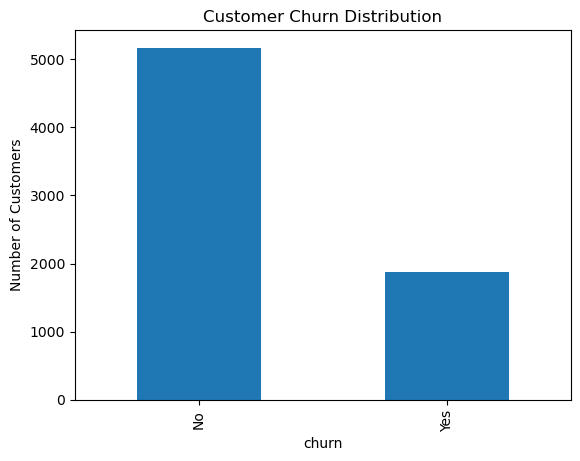

In [14]:
import matplotlib.pyplot as plt

df['churn'].value_counts().plot(
    kind='bar'
)

plt.title('Customer Churn Distribution')
plt.ylabel('Number of Customers')
plt.show()

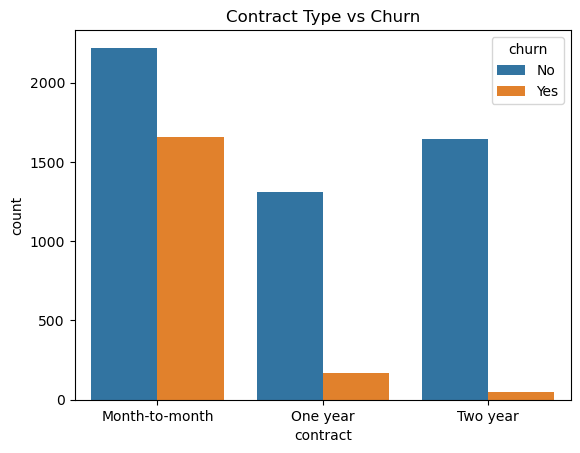

In [15]:
import seaborn as sns

sns.countplot(
    data=df,
    x='contract',
    hue='churn'
)

plt.title('Contract Type vs Churn')
plt.show()

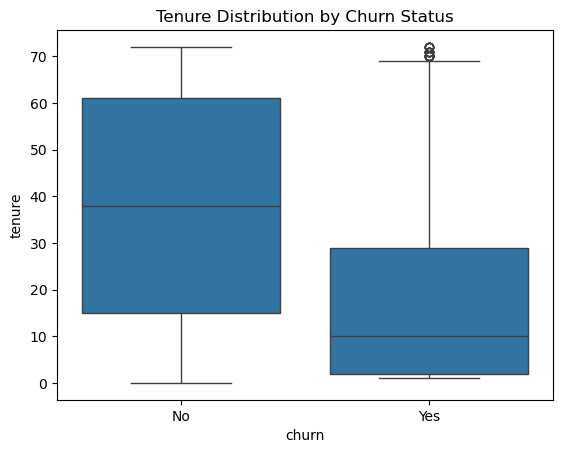

In [16]:
sns.boxplot(
    data=df,
    x='churn',
    y='tenure'
)

plt.title('Tenure Distribution by Churn Status')
plt.show()

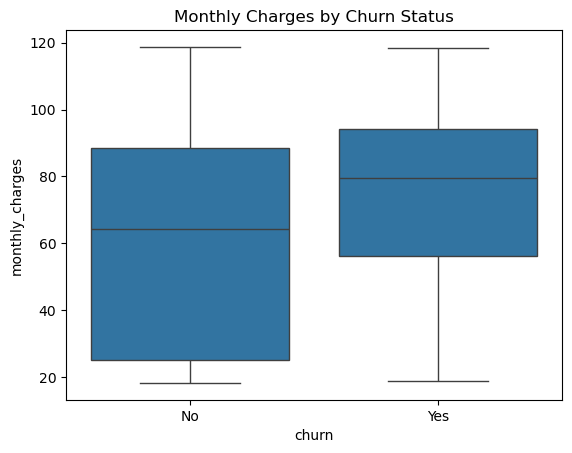

In [17]:
sns.boxplot(
    data=df,
    x='churn',
    y='monthly_charges'
)

plt.title('Monthly Charges by Churn Status')
plt.show()

### Model fitting

In [18]:
df['churn'].value_counts()

churn
No     5174
Yes    1869
Name: count, dtype: int64

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# Split features and target
X = df.drop(columns=['customer_id', 'churn'])
y = df['churn'].map({'No': 0, 'Yes': 1})

# One-hot encode categorical variables
X = df.drop(
    columns=[
        'customer_id',
        'churn',
        'total_charges'
    ]
)
X = pd.get_dummies(X, drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=37,
    stratify=y
)

# Build logistic regression pipeline
logistic_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])

# Train model
logistic_pipeline.fit(X_train, y_train)

# Predict class and probability
y_pred = logistic_pipeline.predict(X_test)
y_prob = logistic_pipeline.predict_proba(X_test)[:, 1]

# Evaluate model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.794889992902768
ROC-AUC: 0.8360097135033197
[[942  93]
 [196 178]]
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1035
           1       0.66      0.48      0.55       374

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



In [25]:
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': logistic_pipeline.named_steps['model'].coef_[0]
}).sort_values('coefficient', ascending=False)

coef_df.head(15)

,feature,coefficient
11,internet_service_Fiber optic,0.684643
33,tenure_group_Loyal,0.365844
24,streaming_movies_Yes,0.192047
10,multiple_lines_Yes,0.183769
27,paperless_billing_Yes,0.167763
22,streaming_tv_Yes,0.151711
29,payment_method_Electronic check,0.097030
0,senior_citizen,0.092094
3,num_additional_services,0.063232
9,multiple_lines_No phone service,0.048195


The Logistic Regression analysis identified internet service type as one of the strongest predictors of customer churn. Customers subscribed to fiber optic internet plans exhibited a significantly higher likelihood of leaving the company compared to other service groups. Additionally, electronic check payments, paperless billing, streaming-related services, and senior citizen status were all associated with an increased risk of churn.

These findings are consistent with the results from the SQL-based business analysis, which also highlighted higher churn rates among fiber optic users, electronic check customers, and senior citizens. Together, the results suggest that customer retention initiatives should prioritize high-risk segments, particularly fiber optic customers and those relying on non-automatic payment methods. By targeting these groups with tailored retention strategies, organizations may be able to reduce customer turnover and improve long-term customer value.

In [27]:
from sklearn.ensemble import RandomForestClassifier

# Build Random Forest pipeline
rf_pipeline = Pipeline([
    ('model', RandomForestClassifier(
        n_estimators=500,
        random_state=37
    ))
])

# Train model
rf_pipeline.fit(X_train, y_train)

# Predict class and probability
y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

# Evaluate model
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7792760823278921
ROC-AUC: 0.8093285799168152
[[925 110]
 [201 173]]
              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1035
           1       0.61      0.46      0.53       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.69      1409
weighted avg       0.77      0.78      0.77      1409



In [31]:
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_pipeline.named_steps['model'].feature_importances_
}).sort_values('importance', ascending=False)

importance_df.head(15)

,feature,importance
1,tenure,0.203493
2,monthly_charges,0.202166
3,num_additional_services,0.049705
11,internet_service_Fiber optic,0.041754
29,payment_method_Electronic check,0.035025
5,gender_Male,0.031738
27,paperless_billing_Yes,0.028659
26,contract_Two year,0.027622
6,partner_Yes,0.026849
14,online_security_Yes,0.026559


The Random Forest model was used to identify the most influential factors associated with customer churn. The results indicate that customer tenure and monthly charges are the two most important predictors, contributing substantially more to the model than any other variable. This suggests that both customer loyalty and pricing play critical roles in determining whether a customer is likely to leave the company.

Other important predictors include the number of additional services subscribed, fiber optic internet service, electronic check payment methods, paperless billing, and contract type. Customers with fiber optic internet plans and those using electronic check payments were identified as higher-risk segments, which is consistent with the findings from both the SQL analysis and Logistic Regression model.

Overall, the Random Forest results highlight that customer retention is influenced by a combination of account tenure, billing characteristics, service subscriptions, and payment behavior. These insights can help organizations prioritize retention efforts toward customer groups that are most vulnerable to churn.

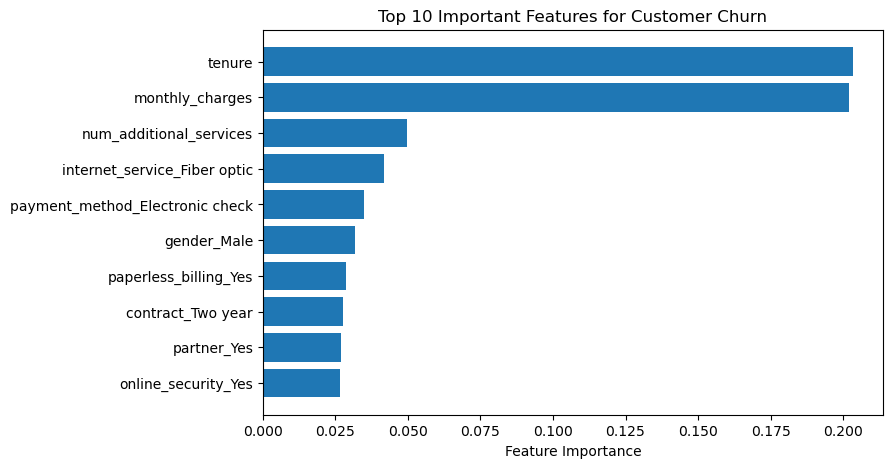

In [33]:
top_features = importance_df.head(10)

plt.figure(figsize=(8, 5))
plt.barh(top_features['feature'], top_features['importance'])
plt.xlabel('Feature Importance')
plt.title('Top 10 Important Features for Customer Churn')
plt.gca().invert_yaxis()
plt.show()

The feature importance analysis shows that tenure and monthly charges are the dominant predictors of churn, with importance scores exceeding 0.20. Their influence is substantially greater than all remaining variables, indicating that customer longevity and monthly spending are the primary factors associated with churn behavior in this dataset.

Logistic Regression identified fiber optic internet service, electronic check payments, and senior citizen status as customer characteristics associated with a higher likelihood of churn. Meanwhile, Random Forest feature importance analysis revealed that customer tenure and monthly charges were the most influential predictors overall. Together, these results suggest that both customer profile characteristics and long-term account behavior play important roles in customer churn.